# Importing all the libaries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
print("All libraries imported successfully!")

All libraries imported successfully!


## Connecting to SQLite Database

In [2]:
conn = sqlite3.connect(r'C:\Users\ASHOK SINGH\Downloads\python\customer_churn.db')

print("Database connected successfully!")

Database connected successfully!


In [3]:
sql_query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(sql_query, conn)

tables

,name
0,db_customer
1,db_subscription
2,db_support


# Importing all the 3 tables 

In [4]:
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [5]:
print("Customer:", df_db_customer.shape)
print("Subscription:", df_db_subscription.shape)
print("Support:", df_db_support.shape)

Customer: (30000, 8)
Subscription: (30000, 11)
Support: (12701, 6)


 # Data Cleaning: Customer Table

In [6]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,NaN
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,NaN
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,NaN


In [7]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   customerid  30000 non-null  str    
 1   name        30000 non-null  str    
 2   country     29997 non-null  str    
 3   state       30000 non-null  str    
 4   gender      30000 non-null  str    
 5   dob         30000 non-null  str    
 6   interests   28489 non-null  str    
 7   pincode     29979 non-null  float64
dtypes: float64(1), str(7)
memory usage: 1.8 MB


In [8]:
df_db_customer.isnull().sum()

customerid       0
name             0
country          3
state            0
gender           0
dob              0
interests     1511
pincode         21
dtype: int64

In [9]:
df_db_customer['customerid'].duplicated().sum()

np.int64(0)

In [10]:
#changing Gender 
df_db_customer['gender'] = df_db_customer['gender'].replace({
    'Men': 'Male',
    'Women': 'Female'
})

# Changing data type

In [11]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,name,country,state,gender,dob,interests,pincode
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10,NaN,NaN
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07,NaN,NaN
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01,NaN,NaN


 # Handle Missing Country Values

In [13]:
state_country_mapping = {
    'Delhi': 'India',
    'Telangana': 'India',
    'Kathmandu': 'Nepal'
}

df_db_customer['country'] = df_db_customer['country'].fillna(
    df_db_customer['state'].map(state_country_mapping)
)

# Remove Unnecessary Columns

In [14]:
df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)


In [15]:
df_db_customer.columns

Index(['customerid', 'name', 'country', 'state', 'gender', 'dob'], dtype='str')

In [16]:
df_db_customer.isnull().sum()

customerid    0
name          0
country       0
state         0
gender        0
dob           0
dtype: int64

# Data Cleaning: Subscription Table

In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               30000 non-null  str    
 1   subscription_start_date  30000 non-null  str    
 2   subscription_type        30000 non-null  str    
 3   renewal_date             30000 non-null  str    
 4   plan_type                30000 non-null  str    
 5   contract_type            30000 non-null  str    
 6   cancellation_date        8973 non-null   str    
 7   cancellation_reason      8973 non-null   str    
 8   monthly_charges          30000 non-null  float64
 9   cltv                     30000 non-null  int64  
 10  churn_score              30000 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 2.5 MB


# Convert Subscription Date Columns to Datetime

In [19]:
date_col = [
    'subscription_start_date',
    'renewal_date',
    'cancellation_date'
]

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

# Check for Duplicate Records

In [20]:
df_db_subscription.isnull().sum()

customerid                     0
subscription_start_date        0
subscription_type              0
renewal_date                   0
plan_type                      0
contract_type                  0
cancellation_date          21027
cancellation_reason        21027
monthly_charges                0
cltv                           0
churn_score                    0
dtype: int64

In [21]:
df_db_subscription.duplicated().sum()

np.int64(0)

In [22]:
df_db_subscription['customerid'].duplicated().sum()

np.int64(0)

In [23]:
print("Subscription Type:")
print(df_db_subscription['subscription_type'].value_counts())

print("\nPlan Type:")
print(df_db_subscription['plan_type'].value_counts())

print("\nContract Type:")
print(df_db_subscription['contract_type'].value_counts())

Subscription Type:
subscription_type
Paid        14542
Organic      7961
Referral     7175
Refferal      322
Name: count, dtype: int64

Plan Type:
plan_type
Standard    14159
Basic        8432
Premium      7409
Name: count, dtype: int64

Contract Type:
contract_type
Monthly    18615
Annual     11385
Name: count, dtype: int64


# Standardize Subscription Type

In [24]:
df_db_subscription['subscription_type'] = (
    df_db_subscription['subscription_type']
    .str.strip()
    .str.title()
)

In [25]:
df_db_subscription['subscription_type'].value_counts()

subscription_type
Paid        14542
Organic      7961
Referral     7175
Refferal      322
Name: count, dtype: int64

# Check for Hidden Characters

In [26]:
df_db_subscription['subscription_type'].unique()

<StringArray>
['Refferal', 'Paid', 'Organic', 'Referral']
Length: 4, dtype: str

In [27]:
df_db_subscription['subscription_type'].map(repr).unique()

<StringArray>
[''Refferal'', ''Paid'', ''Organic'', ''Referral'']
Length: 4, dtype: str

# Standardize Subscription Type Using Explicit Mapping

In [28]:
df_db_subscription['subscription_type'] = (
    df_db_subscription['subscription_type']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'paid': 'Paid',
        'organic': 'Organic',
        'referral': 'Referral'
    })
)

In [29]:
df_db_subscription['subscription_type'].value_counts()

subscription_type
Paid        14542
Organic      7961
Referral     7175
Name: count, dtype: int64

# Validate Numerical Columns

In [30]:
df_db_subscription[['monthly_charges', 'cltv', 'churn_score']].describe()

,monthly_charges,cltv,churn_score
count,30000.000000,30000.000000,30000.000000
mean,14.755238,532.929133,43.058633
std,5.929889,429.575713,26.282398
min,5.490000,42.000000,1.000000
25%,9.060000,183.000000,23.000000
50%,14.350000,415.000000,36.000000
75%,16.470000,774.000000,65.000000
max,92.990000,2329.000000,99.000000


In [31]:
print("Negative Monthly Charges:",
      (df_db_subscription['monthly_charges'] < 0).sum())

print("Negative CLTV:",
      (df_db_subscription['cltv'] < 0).sum())

print("Negative Churn Score:",
      (df_db_subscription['churn_score'] < 0).sum())

Negative Monthly Charges: 0
Negative CLTV: 0
Negative Churn Score: 0


# Validate Subscription Dates

In [32]:
print("Renewal date before subscription start:",
      (df_db_subscription['renewal_date'] < df_db_subscription['subscription_start_date']).sum())

print("Cancellation date before subscription start:",
      (df_db_subscription['cancellation_date'] < df_db_subscription['subscription_start_date']).sum())

Renewal date before subscription start: 0
Cancellation date before subscription start: 0


In [33]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,NaN,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,NaN,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
...,...,...,...,...,...,...,...,...,...,...,...
29995,29996-LBQDF,2020-08-04,Paid,2025-07-09,Premium,Monthly,NaT,NaN,22.13,1414,25
29996,29997-HATJJ,2023-05-29,Paid,2024-11-26,Premium,Monthly,2024-10-27,Switched to competitor,23.94,408,86
29997,29998-GLGHL,2024-10-12,Paid,2025-10-12,Standard,Annual,NaT,NaN,15.37,162,31
29998,29999-PFKII,2024-09-13,Paid,2026-04-11,Basic,Annual,2025-04-11,Poor service,7.96,80,84


In [34]:
print("Shape:", df_db_subscription.shape)

print("\nMissing Values:")
print(df_db_subscription.isnull().sum())

print("\nDuplicate Rows:", df_db_subscription.duplicated().sum())

print("\nDuplicate Customer IDs:",
      df_db_subscription['customerid'].duplicated().sum())

print("\nData Types:")
print(df_db_subscription.dtypes)

Shape: (30000, 11)

Missing Values:
customerid                     0
subscription_start_date        0
subscription_type            322
renewal_date                   0
plan_type                      0
contract_type                  0
cancellation_date          21027
cancellation_reason        21027
monthly_charges                0
cltv                           0
churn_score                    0
dtype: int64

Duplicate Rows: 0

Duplicate Customer IDs: 0

Data Types:
customerid                            str
subscription_start_date    datetime64[us]
subscription_type                     str
renewal_date               datetime64[us]
plan_type                             str
contract_type                         str
cancellation_date          datetime64[us]
cancellation_reason                   str
monthly_charges                   float64
cltv                                int64
churn_score                         int64
dtype: object


In [35]:
df_db_subscription['subscription_type'] = (
    df_db_subscription['subscription_type'].fillna('Unknown')
)

In [36]:
df_db_subscription['subscription_type'].isnull().sum()

np.int64(0)

In [37]:
df_db_subscription['subscription_type'] = (
    df_db_subscription['subscription_type']
    .replace('Unknown', 'Referral')
)

In [38]:
df_db_subscription['subscription_type'].value_counts()

subscription_type
Paid        14542
Organic      7961
Referral     7497
Name: count, dtype: int64

# Data Cleaning: Support Table

In [39]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [40]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 12701 entries, 0 to 12700
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      12701 non-null  str   
 1   complaint_date  12701 non-null  str   
 2   escalations     12701 non-null  str   
 3   csat_score      12701 non-null  int64 
 4   col_1           0 non-null      object
 5   comment         11189 non-null  str   
dtypes: int64(1), object(1), str(4)
memory usage: 595.5+ KB


In [41]:
df_db_support.isnull().sum()

customerid            0
complaint_date        0
escalations           0
csat_score            0
col_1             12701
comment            1512
dtype: int64

In [42]:
df_db_support.duplicated().sum()

np.int64(0)

In [43]:
df_db_support['customerid'].duplicated().sum()

np.int64(2759)

# Remove Unnecessary Columns

In [44]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [45]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


In [46]:
df_db_support.shape

(12701, 4)

# Convert Complaint Date to Datetime

In [47]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [48]:
df_db_support.dtypes

customerid                   str
complaint_date    datetime64[us]
escalations                  str
csat_score                 int64
dtype: object

# Standardize Escalation Values

In [49]:
df_db_support['escalations'] = df_db_support['escalations'].replace({
    'Y': 'Yes',
    'N': 'No'
})

In [50]:
df_db_support['escalations'].value_counts()

escalations
No     9589
Yes    3112
Name: count, dtype: int64

# Check CSAT Score

In [51]:
print("Invalid CSAT Scores:",
      ((df_db_support['csat_score'] < 0) |
       (df_db_support['csat_score'] > 100)).sum())

Invalid CSAT Scores: 0


# create churn flag

In [52]:

df_db_subscription['churn_flag'] = np.where(
    df_db_subscription['cancellation_date'].notna(), 
    1, 
    0
)

In [53]:
df_db_subscription['churn_flag'].value_counts()

churn_flag
0    21027
1     8973
Name: count, dtype: int64

In [54]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [55]:
df.shape

(12701, 5)

# Deleting complaint of user

In [56]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [57]:
df_db_support.shape

(9942, 5)

# Merge Customer 

In [58]:

df = (df_db_subscription
      .merge(df_db_customer, on='customerid', how='left')
      .merge(df_db_support, on='customerid', how='left'))

# Export Final Dataset

In [59]:
df.to_csv('excel_file.csv', index=False)

# Data Analysis 

# 1. Churn Rate

In [60]:
churn_rate = df['churn_flag'].mean() * 100
print("Churn Rate =", round(churn_rate, 2), "%")

Churn Rate = 29.91 %


# 2. Retention Rate

In [61]:
retention_rate = 100 - churn_rate
print("Retention Rate =", round(retention_rate, 2), "%")

Retention Rate = 70.09 %


# 3. Churn by Plan Type

In [62]:
churn_by_plan = df[df['churn_flag'] == 1].groupby('plan_type').agg(
    user_count=('customerid', 'count')
).reset_index()

churn_by_plan

,plan_type,user_count
0,Basic,3562
1,Premium,1623
2,Standard,3788


# 4. Churn by State

In [63]:
churn_by_state = df[df['churn_flag'] == 1].groupby('state').agg(
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

churn_by_state

,state,total_revenue,user_count
0,Andhra Pradesh,6144.90,458
1,Bihar,7296.81,532
2,Chhattisgarh,5302.90,409
3,Delhi,5570.26,431
4,Goa,5812.42,430
5,Gujarat,5894.42,451
6,Haryana,6022.87,457
7,Jharkhand,5725.93,433
8,Karnataka,5816.35,424
9,Kerala,5859.09,435


#5. Churn by Subscription Type

In [64]:
churn_by_subscription = df[df['churn_flag'] == 1].groupby('subscription_type').agg(
    total_revenue=('monthly_charges', 'sum'),
    user_count=('customerid', 'count')
).reset_index()

churn_by_subscription

,subscription_type,total_revenue,user_count
0,Organic,31801.86,2390
1,Paid,57995.72,4363
2,Referral,29992.79,2220


# 6. Average Revenue Per User (ARPU)

In [65]:
arpu = df['monthly_charges'].mean()

print("ARPU =", round(arpu, 2))

ARPU = 14.76


# 7. Average Customer Age

In [66]:
df['dob'] = pd.to_datetime(df['dob'])

today = pd.Timestamp.today()

df['age'] = ((today - df['dob']).dt.days / 365.25).astype(int)

avg_age = df['age'].mean()

print("Average Customer Age =", round(avg_age, 2))

Average Customer Age = 43.25


# 8. Average Customer Lifetime Value (CLTV)

In [67]:
avg_cltv = df['cltv'].mean()

print("Average CLTV =", round(avg_cltv, 2))

Average CLTV = 532.93


# 9. Average Monthly Charges

In [68]:
avg_monthly_charges = df['monthly_charges'].mean()

print("Average Monthly Charges =", round(avg_monthly_charges, 2))

Average Monthly Charges = 14.76


# 10. Churn Rate by Contract Type

In [69]:
churn_by_contract = df.groupby('contract_type').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_contract['churn_rate'] = (
    churn_by_contract['churned_customers'] /
    churn_by_contract['total_customers']
) * 100

churn_by_contract

,contract_type,total_customers,churned_customers,churn_rate
0,Annual,11385,2913,25.586298
1,Monthly,18615,6060,32.554392


# 11. Churn Rate by Gender

In [70]:
churn_by_gender = df.groupby('gender').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_gender['churn_rate'] = (
    churn_by_gender['churned_customers'] /
    churn_by_gender['total_customers']
) * 100

churn_by_gender

,gender,total_customers,churned_customers,churn_rate
0,Female,12513,3787,30.264525
1,Male,17487,5186,29.656316


# 12. Churn Rate by Subscription Type

In [71]:
churn_by_subscription_rate = df.groupby('subscription_type').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_subscription_rate['churn_rate'] = (
    churn_by_subscription_rate['churned_customers'] /
    churn_by_subscription_rate['total_customers']
) * 100

churn_by_subscription_rate

,subscription_type,total_customers,churned_customers,churn_rate
0,Organic,7961,2390,30.021354
1,Paid,14542,4363,30.002751
2,Referral,7497,2220,29.611845


# 13. Churn Rate by Plan Type

In [72]:
churn_by_plan_rate = df.groupby('plan_type').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_plan_rate['churn_rate'] = (
    churn_by_plan_rate['churned_customers'] /
    churn_by_plan_rate['total_customers']
) * 100

churn_by_plan_rate

,plan_type,total_customers,churned_customers,churn_rate
0,Basic,8432,3562,42.243833
1,Premium,7409,1623,21.905790
2,Standard,14159,3788,26.753302


# 14.Churn Rate by Country

In [73]:
churn_by_country = df.groupby('country').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_country['churn_rate'] = (
    churn_by_country['churned_customers'] /
    churn_by_country['total_customers']
) * 100

churn_by_country

,country,total_customers,churned_customers,churn_rate
0,India,29998,8973,29.911994
1,Nepal,2,0,0.000000


# 15. Churn Rate by Escalation Status

In [74]:
churn_by_escalation = df.groupby('escalations').agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_escalation['churn_rate'] = (
    churn_by_escalation['churned_customers'] /
    churn_by_escalation['total_customers']
) * 100

churn_by_escalation

,escalations,total_customers,churned_customers,churn_rate
0,No,7628,3148,41.269009
1,Yes,2314,1680,72.601556


# 16. Churn Rate by CSAT Score

In [75]:
df['csat_group'] = pd.cut(
    df['csat_score'],
    bins=[0, 40, 60, 80, 100],
    labels=['Low', 'Below Average', 'Good', 'Excellent']
)

churn_by_csat = df.groupby('csat_group', observed=True).agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_csat['churn_rate'] = (
    churn_by_csat['churned_customers'] /
    churn_by_csat['total_customers']
) * 100

churn_by_csat

,csat_group,total_customers,churned_customers,churn_rate
0,Low,1297,949,73.168851
1,Below Average,2877,1409,48.974626
2,Good,3038,1368,45.029625
3,Excellent,2730,1102,40.366300


# 17. Churn Rate by Customer Age Group

In [76]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)

churn_by_age = df.groupby('age_group', observed=True).agg(
    total_customers=('customerid', 'count'),
    churned_customers=('churn_flag', 'sum')
).reset_index()

churn_by_age['churn_rate'] = (
    churn_by_age['churned_customers'] /
    churn_by_age['total_customers']
) * 100

churn_by_age

,age_group,total_customers,churned_customers,churn_rate
0,18-25,3408,998,29.284038
1,26-35,6556,2030,30.964002
2,36-45,6626,1991,30.048295
3,46-55,6343,1865,29.402491
4,56+,7067,2089,29.559926


# 18. Average Monthly Charges: Churned vs Active

In [77]:
charges_by_churn = df.groupby('churn_flag').agg(
    total_customers=('customerid', 'count'),
    avg_monthly_charges=('monthly_charges', 'mean')
).reset_index()

charges_by_churn['status'] = charges_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

charges_by_churn

,churn_flag,total_customers,avg_monthly_charges,status
0,0,21027,15.354866,Active
1,1,8973,13.350091,Churned


# 19. Average CLTV: Churned vs Active

In [78]:
cltv_by_churn = df.groupby('churn_flag').agg(
    total_customers=('customerid', 'count'),
    avg_cltv=('cltv', 'mean')
).reset_index()

cltv_by_churn['status'] = cltv_by_churn['churn_flag'].map({
    0: 'Active',
    1: 'Churned'
})

cltv_by_churn

,churn_flag,total_customers,avg_cltv,status
0,0,21027,635.781709,Active
1,1,8973,291.908169,Churned


# 20. Churn Rate by Cancellation Reason

In [79]:
churn_by_reason = df[df['churn_flag'] == 1].groupby(
    'cancellation_reason'
).agg(
    churned_customers=('customerid', 'count')
).reset_index()

churn_by_reason['percentage'] = (
    churn_by_reason['churned_customers'] /
    churn_by_reason['churned_customers'].sum()
) * 100

churn_by_reason.sort_values(
    'churned_customers',
    ascending=False
)

,cancellation_reason,churned_customers,percentage
8,Too expensive,2517,28.050819
6,Switched to competitor,2477,27.605037
4,Poor service,1271,14.164716
7,Technical issues,972,10.832497
2,Not using,899,10.018946
3,Other,834,9.294550
0,Forgot to cancel trial,1,0.011145
1,Not enough content,1,0.011145
5,Poor streaming quality,1,0.011145


# VISUALIZATION

# 1. Overall Churn vs Active Customers

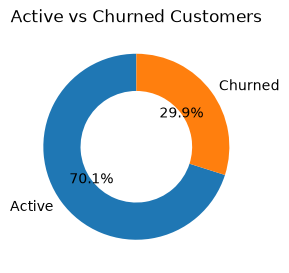

In [80]:
churn_counts = df['churn_flag'].value_counts()

labels = ['Active', 'Churned']
values = [
    churn_counts.get(0, 0),
    churn_counts.get(1, 0)
]

plt.figure(figsize=(3, 4))

plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Active vs Churned Customers')
plt.show()

# 2. Churn Rate by Plan Type

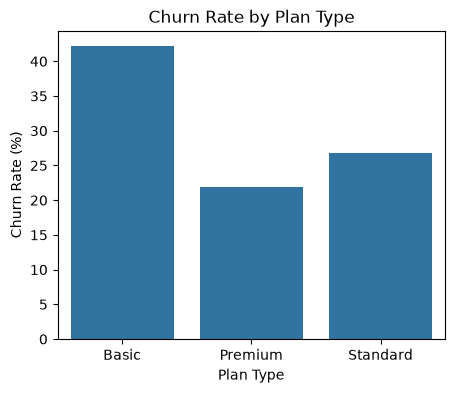

In [81]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=churn_by_plan_rate,
    x='plan_type',
    y='churn_rate'
)

plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')

plt.show()

# 3. Churn Rate by Contract Type

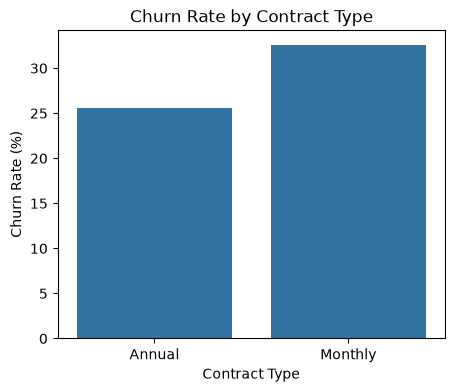

In [82]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=churn_by_contract,
    x='contract_type',
    y='churn_rate'
)

plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')

plt.show()

# 4. Churn Rate by CSAT Group

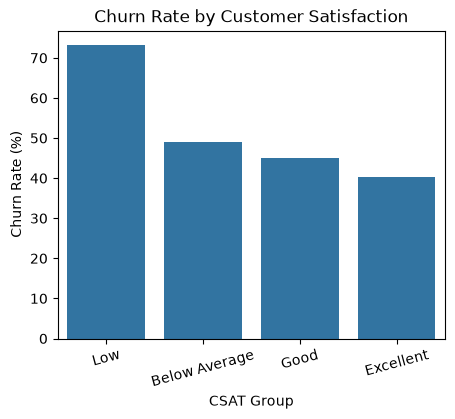

In [83]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=churn_by_csat,
    x='csat_group',
    y='churn_rate'
)

plt.title('Churn Rate by Customer Satisfaction')
plt.xlabel('CSAT Group')
plt.ylabel('Churn Rate (%)')

plt.xticks(rotation=15)

plt.show()

# 5. Churn Rate by Escalation Status

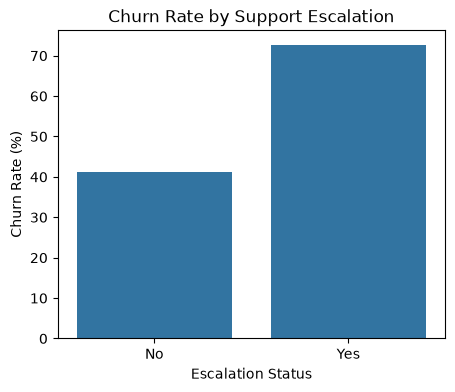

In [84]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=churn_by_escalation,
    x='escalations',
    y='churn_rate'
)

plt.title('Churn Rate by Support Escalation')
plt.xlabel('Escalation Status')
plt.ylabel('Churn Rate (%)')

plt.show()

# 6. Top Cancellation Reasons

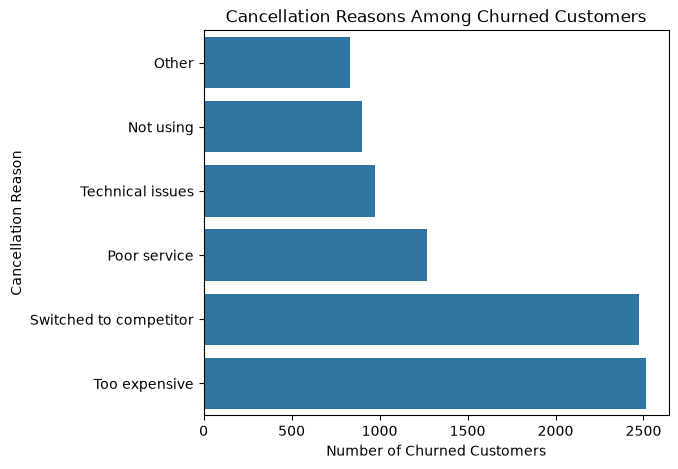

In [85]:
reason_plot = churn_by_reason[
    churn_by_reason['churned_customers'] > 10
].sort_values('churned_customers', ascending=True)

plt.figure(figsize=(6, 5))

sns.barplot(
    data=reason_plot,
    x='churned_customers',
    y='cancellation_reason'
)

plt.title('Cancellation Reasons Among Churned Customers')
plt.xlabel('Number of Churned Customers')
plt.ylabel('Cancellation Reason')

plt.show()

# 7. Churn Rate by Age Group

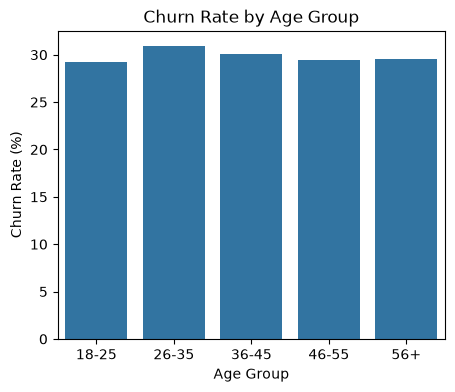

In [86]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=churn_by_age,
    x='age_group',
    y='churn_rate'
)

plt.title('Churn Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Churn Rate (%)')

plt.show()

# 8. CLTV: Active vs Churned

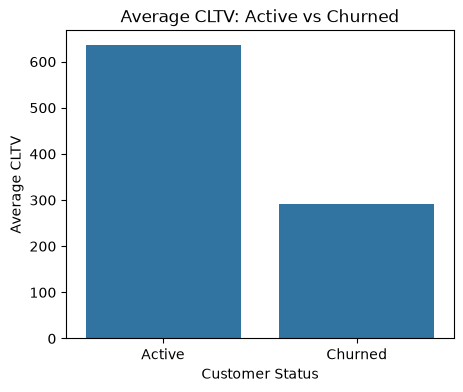

In [87]:
plt.figure(figsize=(5, 4))

sns.barplot(
    data=cltv_by_churn,
    x='status',
    y='avg_cltv'
)

plt.title('Average CLTV: Active vs Churned')
plt.xlabel('Customer Status')
plt.ylabel('Average CLTV')

plt.show()

# Key Findings

1. The overall customer churn rate is 29.91%, while the retention rate is 70.09%.

2. Monthly contract customers have a higher churn rate (32.55%) compared with annual contract customers (25.59%).

3. Basic plan customers have the highest churn rate at 42.24%, compared with Standard at 26.75% and Premium at 21.91%.

4. Customers with low CSAT scores have a very high churn rate of 73.17%, compared with 40.37% among customers with excellent CSAT scores.

5. Customers with escalated support cases have a churn rate of 72.60%, compared with 41.27% for customers without escalations.

6. The most common cancellation reasons are "Too expensive" (28.05%) and "Switched to competitor" (27.61%), together accounting for approximately 55.66% of churned customers.

7. Active customers have a higher average CLTV of 635.78 compared with 291.91 for churned customers.

8. The 26–35 age group has the highest churn rate at 30.98%, although the difference across age groups is relatively small.

# Business Recommendations

1. Review the pricing and benefits of the Basic plan to reduce its high churn rate.

2. Develop retention strategies for monthly contract customers and encourage customers to move toward annual contracts.

3. Focus on improving customer satisfaction, especially among customers with low CSAT scores.

4. Investigate escalated support cases and improve issue resolution to reduce the high churn associated with escalations.

5. Address pricing concerns and competitor switching through targeted offers, competitive pricing, and improved customer benefits.

6. Focus retention efforts on high-value customers to protect customer lifetime value and reduce potential revenue loss.

7. Monitor churn patterns regularly across plans, contracts, customer satisfaction, and support interactions.

 Conclusion

The churn analysis shows that customer churn is strongly associated with several business factors, particularly plan type, contract type, customer satisfaction, support escalations, and cancellation reasons.

The Basic plan, monthly contracts, low CSAT scores, and escalated support cases represent important areas for retention improvement. Pricing concerns and competitor switching are also major reasons for customer loss.

These findings can help the business prioritize customer retention initiatives, improve service quality, optimize pricing and plans, and protect customer lifetime value.